=== Classification Report ===
              precision    recall  f1-score   support

           0       0.98      0.94      0.96       342
           1       0.34      0.61      0.44        18

    accuracy                           0.92       360
   macro avg       0.66      0.77      0.70       360
weighted avg       0.95      0.92      0.93       360

ROC-AUC Score: 0.939


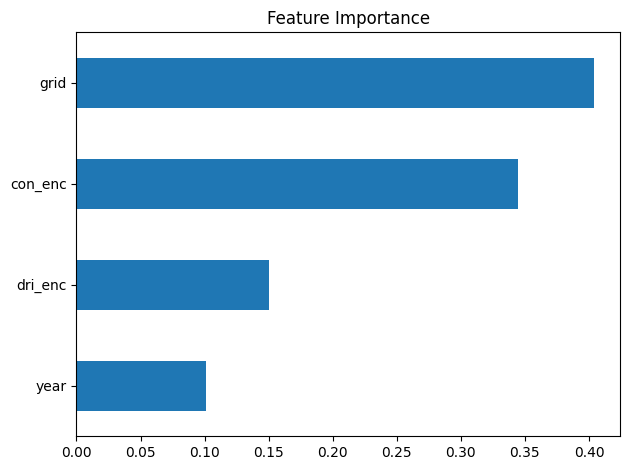

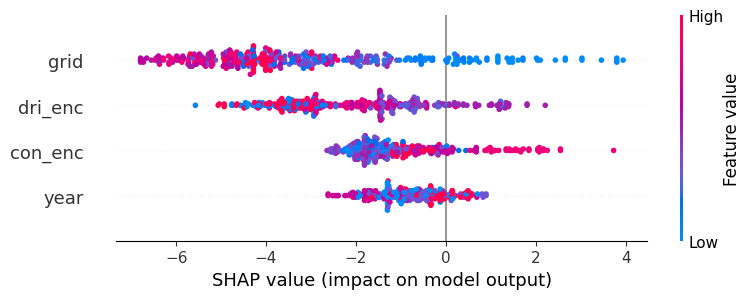

In [76]:
import requests
import time
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import shap

# ── Data Collection ──────────────────────────────────────────────
races = []
for round_num in range(1, 25):
    for year in range(2021, 2025):
        url = f"https://api.jolpi.ca/ergast/f1/{year}/{round_num}/results/"
        response = requests.get(url)
        if response.status_code != 200 or not response.text.strip():
            continue
        data = response.json()
        if not data["MRData"]["RaceTable"]["Races"]:
            continue
        results = data["MRData"]["RaceTable"]["Races"][0]["Results"]
        for r in results:
            r["round"] = round_num
            r["year"] = year
            races.append(r)
        time.sleep(0.2)

# ── Feature Engineering ──────────────────────────────────────────
df = pd.DataFrame(races)
df['Constructor_Id'] = df['Constructor'].apply(lambda x: x['constructorId'])
df['driver_Id']      = df['Driver'].apply(lambda x: x['driverId'])
df['is_winner']      = (df['position'] == '1').astype(int)
df['points']         = df['points'].astype(float)
df['grid']           = df['grid'].astype(int)
df['year']           = df['year'].astype(int)

# ── Train/Test Split BEFORE Encoding (prevents leakage) ──────────
x_raw = df[['Constructor_Id', 'driver_Id', 'year', 'grid']]
y     = df['is_winner']

x_train_raw, x_test_raw, y_train, y_test = train_test_split(
    x_raw, y, test_size=0.2, random_state=42, stratify=y
)

# ── Encode on Train, Transform on Test ───────────────────────────
le_con = LabelEncoder()
le_dri = LabelEncoder()

x_train = x_train_raw.copy()
x_test  = x_test_raw.copy()

x_train['con_enc'] = le_con.fit_transform(x_train_raw['Constructor_Id'])
x_test['con_enc']  = le_con.transform(x_test_raw['Constructor_Id'])

x_train['dri_enc'] = le_dri.fit_transform(x_train_raw['driver_Id'])
x_test['dri_enc']  = le_dri.transform(x_test_raw['driver_Id'])

x_train = x_train[['con_enc', 'dri_enc', 'year', 'grid']]
x_test  = x_test[['con_enc', 'dri_enc', 'year', 'grid']]

# ── Model Training ───────────────────────────────────────────────
pos = (y_train == 1).sum()
neg = (y_train == 0).sum()

model = XGBClassifier(scale_pos_weight=(neg / pos), random_state=42)
model.fit(x_train, y_train)

# ── Evaluation ───────────────────────────────────────────────────
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:, 1]

print("=== Classification Report ===")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.3f}")

# ── Feature Importance ───────────────────────────────────────────
feat_imp = pd.Series(model.feature_importances_, index=x_train.columns)
feat_imp.sort_values().plot(kind='barh', title='Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

# ── SHAP Explainability ──────────────────────────────────────────
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(x_test)
shap.summary_plot(shap_values, x_test)